In [29]:
import mesa
import numpy as np
from collections import Counter, defaultdict


In [30]:
class VoterAgent(mesa.Agent):
    """An Voter Agent who Ranks Candidates based on Political Leanings."""
    def __init__(self, id, model):
        super().__init__(id, model)
        self.political_leaning = np.random.uniform(0, 1) # (0 = left, 1 = right)
        self.approval_threshold = np.random.uniform(0.1, 0.5) # Threshold for approval voting
        # Stores Candidates Ordered by Preference
        self.ranked_vote = [] 

    def step(self):
        """Rank Candidates and Vote."""
        candidates = [c for c in self.model.schedule.agents if isinstance(c, CandidateAgent)]
        
        if not candidates:
            return

        dist_list = []
        for c in candidates:
            dist = abs(self.political_leaning - c.political_position)
            dist_list.append((c, dist))

        # Sort candidates by distance to political leaning
        dist_list.sort(key=lambda x: x[1])

        # Store the ranked candidates
        self.ranked_vote = [c[0] for c in dist_list]


In [31]:
class CandidateAgent(mesa.Agent):
    """A Candidate Agent with a Political Position."""
    def __init__(self, id, model):
        super().__init__(id, model)
        self.political_position = np.random.uniform(0, 1) # (0 = left, 1 = right)
        self.vote_count = 0         # Tracks first-choice votes

    def step(self):
        # No action yet for this version
        pass

In [32]:
class ElectionModel(mesa.Model):
    """Election Model. Runs Both Plurality Voting and IRV for Comparison."""
    def __init__(self, num_voters, num_candidates):
        super().__init__()
        self.num_voters = num_voters
        self.num_candidates = num_candidates
        self.plurality_winner = None    # Track plurality winner
        self.irv_winner = None          # Track IRV winner
        self.approval_winner = None     # Track Approval winner

        # Activate agents randomly
        self.schedule = mesa.time.RandomActivation(self)
        
        # Create Voters
        for i in range(self.num_voters):
            v = VoterAgent(f"v{i}", self)
            self.schedule.add(v)
        
        # Create Candidates
        for i in range(self.num_candidates):
            c = CandidateAgent(f"c{i}", self)
            self.schedule.add(c)

    def step(self):
        """Advance the model by one step and run both voting methods."""
        # Run the agents
        self.schedule.step()

        # Run plurality voting
        print("\n===== PLURALITY VOTING =====")
        self._tally_plurality()
        self._determine_plurality_winner()
        
        # Run IRV voting
        print("\n===== INSTANT RUNOFF VOTING (IRV) =====")
        self._irv_election()

        # Run Approval Voting
        print("\n===== APPROVAL VOTING =====")
        self._approval_voting()
        
        # Compare the results
        self._announce_winner()

    ### PLURALITY VOTING ###
    def _tally_plurality(self):
        """Tally votes for each candidate."""
        for agent in self.schedule.agents:
            if isinstance(agent, CandidateAgent):
                agent.vote_count = 0

        # Count first-choices votes for each candidate
        for agent in self.schedule.agents:
            if isinstance(agent, VoterAgent) and agent.ranked_vote:
                # Only count the first choice vote
                first_choice = agent.ranked_vote[0]
                first_choice.vote_count += 1


    def _determine_plurality_winner(self):
        """Determine the winner of the election (by Plurality)."""
        max_votes = -1
        potential_winners = []          # For Handling ties
        candidates = [c for c in self.schedule.agents if isinstance(c, CandidateAgent)]

        print(f'-- Plurality Election Results --')
        print(f"Total Candidates: {len(candidates)}")
        for candidate in candidates:
            # Prin the average distance of the candidate to the voters
            avg_distance = np.mean([abs(voter.political_leaning - candidate.political_position) for voter in self.schedule.agents if isinstance(voter, VoterAgent)])
            print(f"Candidate {candidate.unique_id} (Position: {candidate.political_position:.2f}) - Votes: {candidate.vote_count} - Avg. Distance: {avg_distance:.2f}")
            if candidate.vote_count > max_votes:
                max_votes = candidate.vote_count
                potential_winners = [candidate]
            elif candidate.vote_count == max_votes:
                potential_winners.append(candidate)

        # Handle potentital ties through random selection
        if potential_winners:
            self.plurality_winner = np.random.choice(potential_winners)
        else:
            self.plurality_winner = None

    
    ### IRV VOTING ###
    def _irv_election(self):
        """Run IRV Election Process"""
        print(f'-- IRV Election Process --')
        voters = [v for v in self.schedule.agents if isinstance(v, VoterAgent)]
        active_candidates = {c for c in self.schedule.agents if isinstance(c, CandidateAgent)}      # Set for active candidates
        total_votes_cast = len(voters)       # Total votes cast
        majority_threshold = total_votes_cast / 2
        round_number = 1

        # Simulate IRV rounds until a winner is found or all candidates are eliminated
        while len(active_candidates) > 1:
            print(f'\nRound {round_number} - Candidates Remaining: {[c.unique_id for c in active_candidates]}')
            first_choice_votes = {c: 0 for c in active_candidates}
            voter_effective_votes = {}  # Track effective votes for each voter

            # Tally first-choice votes
            for v in voters:
                found_preference = False    # Flag to check if a preference was found
                for c in v.ranked_vote:
                    if c in active_candidates:
                        first_choice_votes[c] += 1
                        voter_effective_votes[v] = c # Track the effective vote for the voter
                        found_preference = True
                        break
                # If no preference was found, the vote is not counted
                if not found_preference:
                    voter_effective_votes[v] = None

            # Print results
            sorted_counts = sorted(first_choice_votes.items(), key=lambda x: x[1], reverse=True)
            for candidate, count in sorted_counts:
                # Calculate average distance of the candidate to ALL voters
                avg_distance = np.mean([abs(voter.political_leaning - candidate.political_position) for voter in voters if isinstance(voter, VoterAgent)])
                print(f"Candidate {candidate.unique_id} (Pos: {candidate.political_position:.2f} - Votes: {count} ({(count/total_votes_cast)*100:.1f}%) - Avg. Dist: {avg_distance:.2f})")

            # Check for Majority Winner
            if sorted_counts and sorted_counts[0][1] > majority_threshold:
                self.irv_winner = sorted_counts[0][0]
                print(f"\nWinner: {self.irv_winner.unique_id} (Position: {self.irv_winner.political_position:.2f})")
                return

            # Check if remaining candidates are tied
            if len(sorted_counts) > 1 and len(set(first_choice_votes.values())) == 1:
                print("All remaining candidates are tied. No winner.")
                return

            # Eliminate the candidate with the fewest votes
            min_votes = float('inf') 
            to_eliminate = []
            if sorted_counts:
                min_votes = sorted_counts[-1][1]
                to_eliminate = [c for c, count in first_choice_votes.items() if count == min_votes] # Eliminate all candidates with the minimum votes

            if not to_eliminate and len(active_candidates) > 0:
                # Handle case where candidates might get 0 votes initially or after redistribution
                min_votes = 0
                candidates_w_0_votes = [c for c in active_candidates if c not in first_choice_votes]
                if candidates_w_0_votes:
                    to_eliminate = candidates_w_0_votes
                elif active_candidates:     # If all candidates have votes, but no one has the minimum votes
                    raise Exception("Error in IRV elimination process. No candidates to eliminate.")

            if not to_eliminate and active_candidates:
                raise Exception("Error in IRV elimination process. Could not determine candidates to eliminate.")

            # Eliminate candidates
            # Usually only one candidate will be eliminated, but for tied candidates, we may eliminate multiple
            for c in to_eliminate:
                print(f"Eliminating Candidate {c.unique_id} with {min_votes} votes.")
                active_candidates.remove(c)

            if len(active_candidates) == 1:
                self.irv_winner = list(active_candidates)[0]
                print(f"\nOnly one candidate remaining. Winner: {self.irv_winner.unique_id} (Position: {self.irv_winner.political_position:.2f})")
                return
            
            round_number += 1

        if len(active_candidates) == 1:
            self.irv_winner = list(active_candidates)[0]
            print(f"\nWinner: {self.irv_winner.unique_id} (Position: {self.irv_winner.political_position:.2f})")
        else:
            print("No winner could be determined. All candidates eliminated.")
            self.irv_winner = None

    ### APPROVAL VOTING ###
    def _approval_voting(self):
        """Run Approval Voting."""
        print(f'-- Aproval Voting Results --')
        voters = [v for v in self.schedule.agents if isinstance(v, VoterAgent)]
        candidates = [c for c in self.schedule.agents if isinstance(c, CandidateAgent)]
        approval_counts = defaultdict(int)

        # Tally approval votes for each candidate
        for v in voters:
            for c in candidates:
                dist = abs(v.political_leaning - c.political_position)
                if dist < v.approval_threshold:
                    approval_counts[c] += 1

        max_approvals = -1
        potential_winners = []

        sorted_approvals = sorted(approval_counts.items(), key=lambda x: x[1], reverse=True)

        print(f'Total Candidates: {len(candidates)}')
        for candidate, count in sorted_approvals:
            # Calculate average distance of the candidate to ALL voters
            avg_distance = np.mean([abs(voter.political_leaning - candidate.political_position) for voter in voters if isinstance(voter, VoterAgent)])
            print(f'Candidate {candidate.unique_id} (Position: {candidate.political_position:.2f}) - Approvals: {count} ({(count/len(voters))*100:.1f}%) - Avg. Dist: {avg_distance:.2f}')
            if count > max_approvals:
                max_approvals = count
                potential_winners = [candidate]
            elif count == max_approvals:
                potential_winners.append(candidate)

        if potential_winners:
            self.approval_winner = np.random.choice(potential_winners)
            print(f'\nWinner: {self.approval_winner.unique_id} (Position: {self.approval_winner.political_position:.2f})')
        else:
            self.approval_winner = None
            print("No winner determined.")


        

    ### ANNOUNCE WINNER ###
    def _announce_winner(self):
        """Compare and announce the voting results from both methods."""
        print("\n===== ELECTION COMPARISON =====")
        print("PLURALITY WINNER: ", end="")
        if self.plurality_winner:
            print(f"Candidate {self.plurality_winner.unique_id} (Position: {self.plurality_winner.political_position:.2f})")
        else:
            print("No winner determined.")
            
        print("IRV WINNER: ", end="")
        if self.irv_winner:
            print(f"Candidate {self.irv_winner.unique_id} (Position: {self.irv_winner.political_position:.2f})")
        else:
            print("No winner determined.")
            
        print("APPROVAL WINNER:  ", end="")
        if self.approval_winner:
            print(f"Candidate {self.approval_winner.unique_id} (Position: {self.approval_winner.political_position:.2f})")
        else:
            print("No winner determined.")

        # Comparison Logic
        winners = {self.plurality_winner, self.irv_winner, self.approval_winner}
        winners.discard(None) # Remove None if any method had no winner

        if len(winners) == 1 and self.plurality_winner is not None: # Check if not empty set
             print(f"\nALL METHODS ELECTED THE SAME CANDIDATE: {list(winners)[0].unique_id}")
        elif len(winners) > 1:
             print("\nDIFFERENT WINNERS BETWEEN METHODS!")
        elif len(winners) == 0:
             print("\nNO WINNER DETERMINED BY ANY METHOD.")


        print('-- End of Election --\n')


In [35]:
# Simple Preferences
model = ElectionModel(num_voters=1000, num_candidates=5)

model.step()


===== PLURALITY VOTING =====
-- Plurality Election Results --
Total Candidates: 5
Candidate c4 (Position: 0.59) - Votes: 172 - Avg. Distance: 0.26
Candidate c3 (Position: 0.02) - Votes: 176 - Avg. Distance: 0.49
Candidate c2 (Position: 0.38) - Votes: 261 - Avg. Distance: 0.27
Candidate c1 (Position: 0.87) - Votes: 285 - Avg. Distance: 0.37
Candidate c0 (Position: 0.54) - Votes: 106 - Avg. Distance: 0.25

===== INSTANT RUNOFF VOTING (IRV) =====
-- IRV Election Process --

Round 1 - Candidates Remaining: ['c0', 'c4', 'c2', 'c1', 'c3']
Candidate c1 (Pos: 0.87 - Votes: 285 (28.5%) - Avg. Dist: 0.37)
Candidate c2 (Pos: 0.38 - Votes: 261 (26.1%) - Avg. Dist: 0.27)
Candidate c3 (Pos: 0.02 - Votes: 176 (17.6%) - Avg. Dist: 0.49)
Candidate c4 (Pos: 0.59 - Votes: 172 (17.2%) - Avg. Dist: 0.26)
Candidate c0 (Pos: 0.54 - Votes: 106 (10.6%) - Avg. Dist: 0.25)
Eliminating Candidate c0 with 106 votes.

Round 2 - Candidates Remaining: ['c4', 'c2', 'c1', 'c3']
Candidate c2 (Pos: 0.38 - Votes: 285 (28.

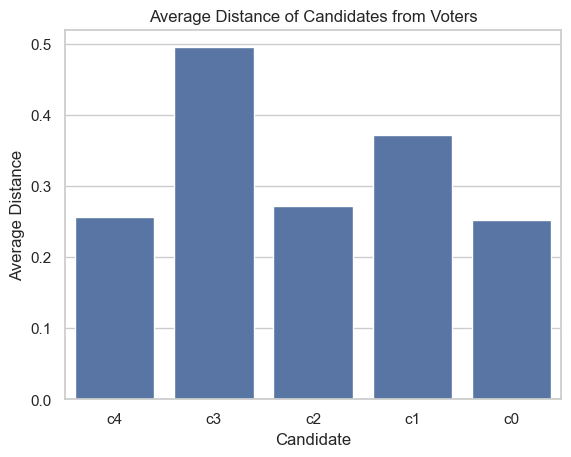

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Plot the average distance of each candidate from the voters in a bar graph
def plot_candidate_distances(model):
    distances = []
    candidates = [c for c in model.schedule.agents if isinstance(c, CandidateAgent)]

    for candidate in candidates:
        dist = np.mean([abs(voter.political_leaning - candidate.political_position) for voter in model.schedule.agents if isinstance(voter, VoterAgent)])
        distances.append((candidate.unique_id, dist))

    df = pd.DataFrame(distances, columns=["Candidate", "Average Distance"])
    sns.barplot(x="Candidate", y="Average Distance", data=df)
    plt.title("Average Distance of Candidates from Voters")
    plt.show()

# Call the function to plot the distances
plot_candidate_distances(model)


In [43]:
def plot_voter_distributions_by_candidate(model):
    """
    Generates a violin plot showing the distribution of political leanings
    for voters who chose each candidate first (plurality) vs. those who didn't,
    overlayed with the candidate's own political position.
    """
    voters = [v for v in model.schedule.agents if isinstance(v, VoterAgent)]
    candidates = [c for c in model.schedule.agents if isinstance(c, CandidateAgent)]

    plot_data = []
    candidate_positions = {}

    # Get candidate positions and sort order
    for candidate in sorted(candidates, key=lambda c: c.unique_id): # Ensure consistent order
        candidate_positions[candidate.unique_id] = candidate.political_position
    candidate_order = list(candidate_positions.keys())

    # Collect data: Voter leaning vs. Candidate vs. Vote Status
    for voter in voters:
        if not voter.ranked_vote:
            continue # Skip voters who didn't rank

        first_choice_candidate = voter.ranked_vote[0]

        for candidate in candidates:
            if candidate == first_choice_candidate:
                status = f"Voted For {candidate.unique_id}"
            else:
                status = f"Did Not Vote For {candidate.unique_id}"

            plot_data.append({
                "Candidate": candidate.unique_id,
                "Voter Leaning": voter.political_leaning,
                "Vote Status": status
            })

    if not plot_data:
        print("No voter choices recorded to plot.")
        return

    df = pd.DataFrame(plot_data)

    # --- Create the plot ---
    plt.figure(figsize=(15, 8)) # Adjusted figure size

    # Create a combined status for hue mapping to simplify legend/colors
    df['Plot Status'] = df.apply(lambda row: 'Voted For' if row['Vote Status'].startswith('Voted For') else 'Did Not Vote For', axis=1)

    # Violin plot for voter leaning distributions using split violins
    sns.violinplot(
        x="Candidate",
        y="Voter Leaning",
        hue="Plot Status", # Use combined status for hue
        data=df,
        order=candidate_order,
        split=True,      # Show 'Voted For' and 'Did Not Vote For' in one violin
        inner="quartile",# Show quartiles inside violins
        palette={"Voted For":"skyblue", "Did Not Vote For":"lightcoral"}, # Assign colors
        linewidth=1
    )

    # Overlay candidate positions using stripplot
    candidate_pos_df = pd.DataFrame({
        'Candidate': candidate_order,
        'Position': [candidate_positions[c] for c in candidate_order]
    })

    # Use stripplot, ensure x-values match violin plot categories
    sns.stripplot(
        x='Candidate',
        y='Position',
        data=candidate_pos_df,
        order=candidate_order,
        marker='D',    # Diamond marker
        s=10,          # Size of the marker
        color='black', # Use black for better visibility
        label='Candidate Position', # Label for the legend
        jitter=False   # Don't jitter points
    )


    plt.title('Distribution of Voter Leanings: Voted For vs. Did Not Vote For (Plurality First Choice)')
    plt.xlabel('Candidate')
    plt.ylabel('Political Leaning (0=Left, 1=Right)')
    plt.ylim(-0.05, 1.05) # Adjust ylim slightly for markers
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # --- Create Legend ---
    # Get handles and labels from the plot
    handles, labels = plt.gca().get_legend_handles_labels()

    # Identify the unique handles/labels we want in the legend
    # The violinplot creates two patches per split violin, stripplot adds points.
    # We need handles for 'Voted For', 'Did Not Vote For', and 'Candidate Position'.
    legend_elements = {}
    for handle, label in zip(handles, labels):
        if label == "Voted For" and label not in legend_elements:
             legend_elements[label] = handle
        elif label == "Did Not Vote For" and label not in legend_elements:
             legend_elements[label] = handle
        elif label == 'Candidate Position' and label not in legend_elements:
             # For stripplot, the handle might just be a line. We can use its color.
             # Or create a custom marker handle if needed. Let's try using its default handle.
             legend_elements[label] = handle


    # Recreate the legend with desired elements
    plt.legend(handles=legend_elements.values(), labels=legend_elements.keys(), title="Legend", loc='best')
    #---------------------

    plt.tight_layout()
    plt.show()

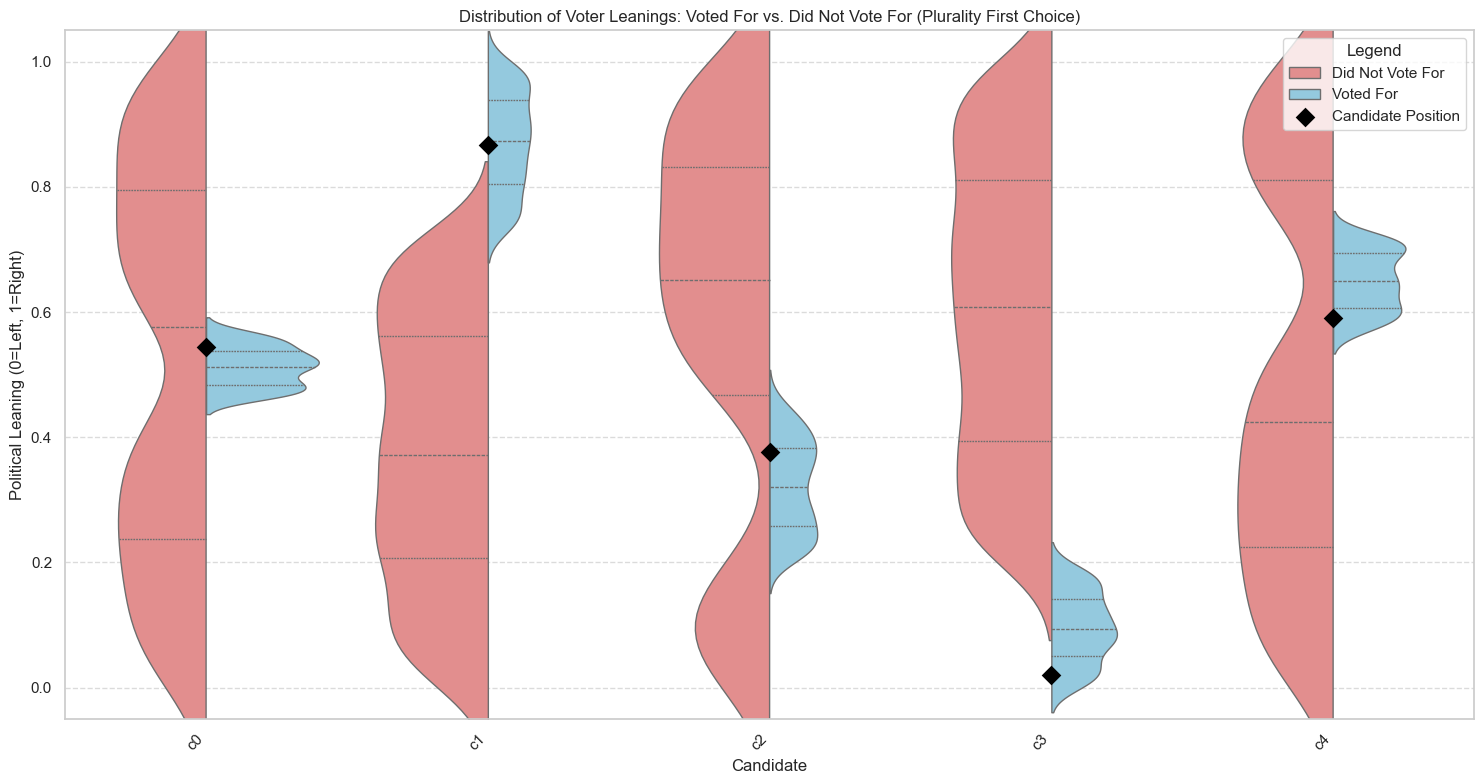

In [44]:
plot_voter_distributions_by_candidate(model)